In [1]:
from data_loader import DataLoader
from data_preprocessing import Preprocessing
from modeling import TrainProphet, ForecastProphet
from hypertuning import ProphetTuner
import pandas as pd
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

d:\My Dcument\Python Scripts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load Data
loader = DataLoader("BBCA", "2020-01-01", "2026-03-20")
df = loader.load_data()

preparation = Preprocessing()
df_resample = preparation.run(df)

#Train Model (Base)
train = TrainProphet(df_resample, window=670)
TrainProphet(df_resample)
train_res=train.run()

22:31:03 - cmdstanpy - INFO - Chain [1] start processing
22:31:04 - cmdstanpy - INFO - Chain [1] done processing
22:31:05 - cmdstanpy - INFO - Chain [1] start processing
22:31:06 - cmdstanpy - INFO - Chain [1] done processing


In [3]:
model = train_res[0]
end_date_train = train_res[1]

start_forecast_date = (datetime.strptime(end_date_train, '%Y-%m-%d')+ timedelta(days=1)).strftime('%Y-%m-%d')
end_forecast_date = (datetime.strptime(end_date_train, '%Y-%m-%d')+ timedelta(days=5)).strftime('%Y-%m-%d')

forecast = ForecastProphet(model, start_forecast_date, end_forecast_date)
df_forecast = forecast.run().reset_index(drop=True)

additional day= 1


In [4]:
#compare with actual data

min_date_ = df_forecast['ds'].min().strftime('%Y-%m-%d')
max_date_ = df_forecast['ds'].max().strftime('%Y-%m-%d')

loader_act = DataLoader("BBCA", min_date_, max_date_)
df_act = loader_act.load_data()
df_act['Date'] = df_act.index
df_act = df_act[['Date','Close']]
df_act.reset_index(drop=True, inplace=True)
df_act = pd.DataFrame({'Date':df_act.iloc[:,0].tolist(), 'Close':df_act.iloc[:,1].tolist()})

In [5]:
df_merge = pd.merge(df_forecast[['ds','yhat']], df_act, how='left', left_on='ds', right_on = 'Date')
df_merge = df_merge[['ds','yhat','Close']].dropna()

# Evaluation
rmse = mean_squared_error(df_merge['Close'], df_merge['yhat'])
mae = mean_absolute_error(df_merge['Close'], df_merge['yhat'])
mape = mean_absolute_percentage_error(df_merge['Close'], df_merge['yhat']) * 100

print("----------------------------------------------------")
print("Metrics Evaluation")
print('rmse:', rmse, ", mae:", mae, ", mape:", mape )

----------------------------------------------------
Metrics Evaluation
rmse: 33.922126713442964 , mae: 5.770279933781947 , mape: 6.238735837617328


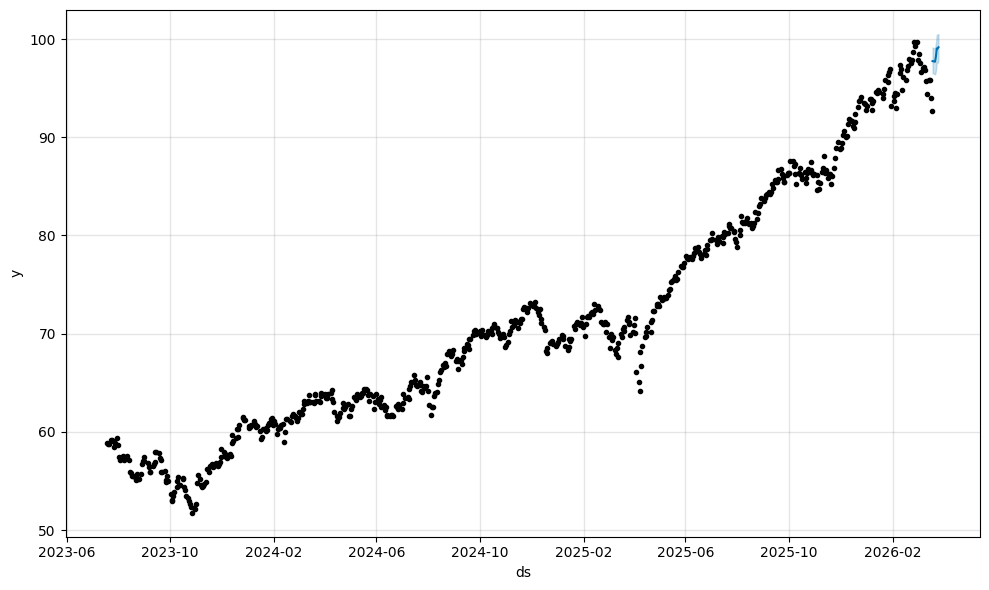

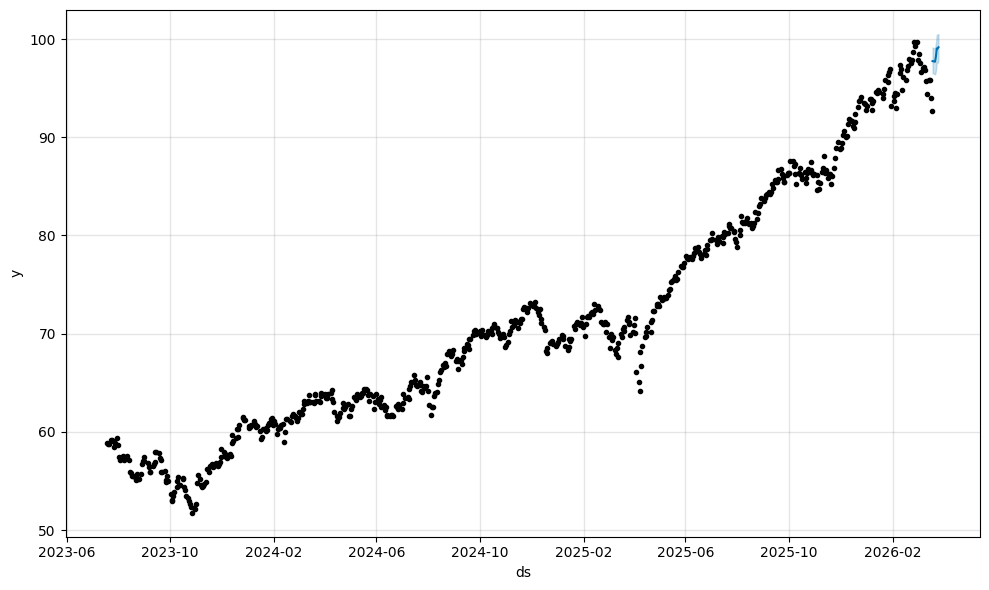

In [6]:
model.plot(df_forecast)

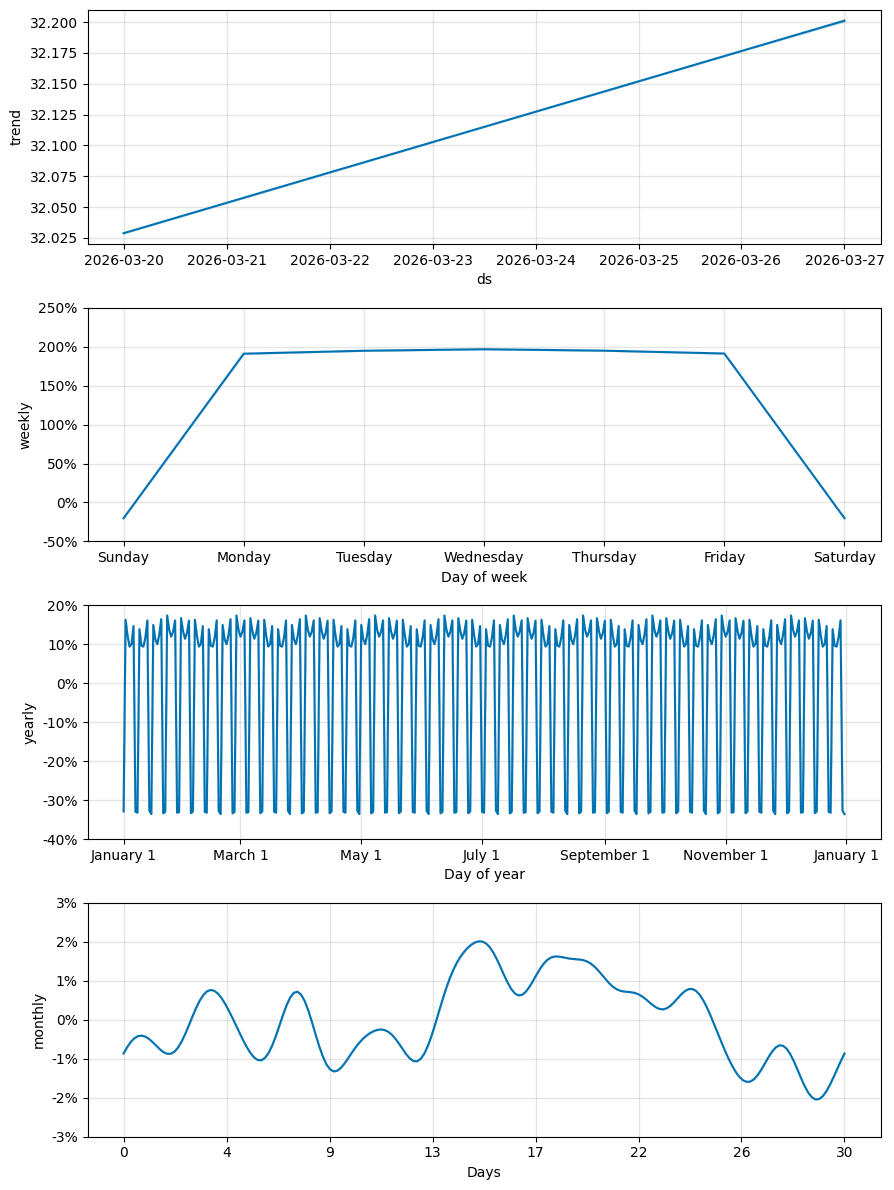

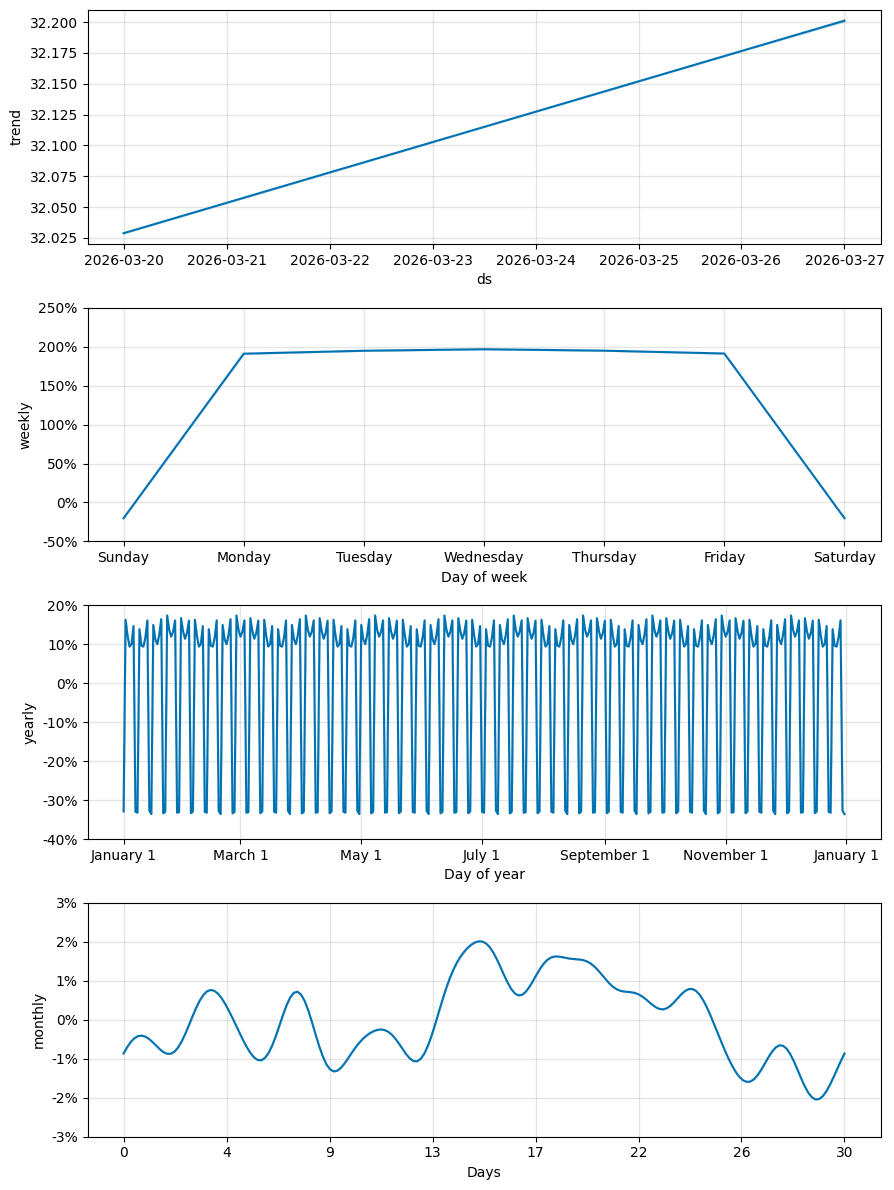

In [7]:
# plot component of forecast results
model.plot_components(df_forecast)

In [8]:
# plot data

import plotly.express as px
import plotly.graph_objects as go 

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_merge["ds"], y=df_merge["Close"], name="Actual", mode="lines"))
fig.add_trace(go.Scatter(x=df_merge["ds"], y=df_merge["yhat"], name="Forecast", mode="lines"))
fig.show()

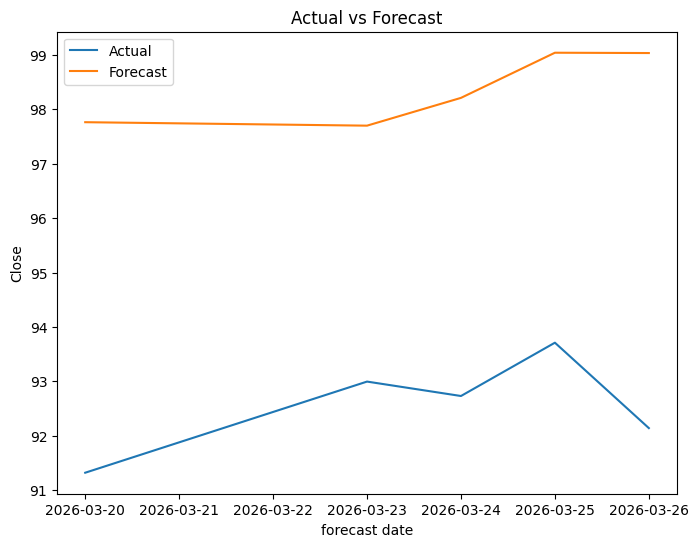

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.lineplot(data=df_merge, x="ds", y="Close", label="Actual")
sns.lineplot(data=df_merge, x="ds", y="yhat", label="Forecast")

plt.title("Actual vs Forecast")
plt.xlabel("forecast date")
plt.legend()

plt.show()